## Testing how payload position affects the Attitude Control System fro an Orbital Transfer Vehicle

### Background
The Attitude Control System(ACS) on spaceships plays a critical role in ship safety, vehicle control, and mission execution. Advanced ACS schemes must be thoughtout for large vehicles such as the Blue Ring, which is an Orbital Transfer Vehicle(OTV). Large vehicles like this require lots of energy to overcome rotational inertia so the ACS must be tuned correctly. The Blue Ring is designed to transport satellites over large altitude distances. The ACS has an increasing challenge when transporting vehicles because of the unique inertia added to it's body. Changing the inertia of the body changes the system that the controller is used to.


In this script I investigate how the inertia of a payload affects the performance of an attitude controller. We will test a simplified PD controller that operates on the error of the orientation angle, and angular rate of the OTV.

A few simplification were utilized to complete this thought experiment. 
- The inertia of the Blue Ring OTV was simplified to a cylinder.
- The inertia of the payload was simplified to a cube.
- Actuators that apply torques in the principal axes are deterministic, without delay, or saturation.
- There is no noise in the sensors, controllers, acutators, or system. The experiment is deterministic.

Setup:
- A cube(Payload) is attached tangent to the curved surface of the cylinder(OTV)
- Vary the position of the 

Important Equations:
- Dynamics are described by the Euler Rotation Equations
-- this is great for describing the rotation of a rigid floating body, because all components are defined in the rotating reference frame(OTV)
-- i.e. this applies to our problem because the actuators that apply the torque's in the rotating frame of the vehicle.
- The dynamics described by differential equations are propogated forward using Euler Integration. This is a standard simplified method for estimating continuous differential equations. Accuracy is decent by not the best technique. 
- The Parallel Axis Theorem was used to estimate the moment of inertia of the composite shape, OTV + Payload. This theorem allows us to estimate the moment of inertia of the payload when we rotate it about an axis that is parallel to it's centroidal axis. In our case, when the payload is attached to the outside of the OTV, it will rotate about the principal axes of the OTV.

Hypothesis:
The controller should have a harder time stabilizing the system when the mass of the payload is docked further from the princpal axes. From physics class we learned that we can increase our rotational inertia by extending mass away from our body, i.e. it is harder to spin us when mass is further from our body. This will make it harder for the controller to stabilize the system because the rotational inertia is larger than the system it was tuned for.

Further Research:
- Higher fidelity model using RungeKutta.
- Better accuracy model by improving the inertia estimates of the Blue Ring. 
- Better controllers. LQR, MPC, gain scheduling.
- Incorporating estimates of noise in the model for the system or measurement devices.
- Statistics on the probablity of achieved stabilization in a stochastic system. PDF representing the likelhood of stability within the performance metrics(rise/settling time).

In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
class OrbitalTransferVehicle:
    def __init__(self, t_span, z_pay, m_body = 2000, r_body = 2.5, h_body = 5, m_pay = 500, s_pay = 1, K_p = 20, K_d = 400):
        """
        Initialize the OTV.
        """
        self.delta_t = 0.01
        self.x = np.zeros((6, 1))  # initial conditions for the state vector
        self.t = 0.0
        self.t_span = t_span # final time of simulation

        self.m_body = m_body
        self.r = r_body
        self.h = h_body

        self.m_pay = m_pay  # mass of payload
        self.s_pay = s_pay
        self.x_pay = 0
        self.y_pay = r_body + s_pay / 2 # distance from the center of mass to the payload in y direction
        self.z_pay = z_pay

        self.I = self.set_inertia()

        self.K_p = K_p
        self.K_d = K_d
    
    def set_inertia(self):
        """
        Set the inertia matrix based on the mass of the payload.
        """
        # Inertia matrix for a cylindrical body
        m = self.m_body
        r = self.r
        h = self.h

        I_cyc = np.array([1/12*m*(3*r**2 + h**2), 1/12*m*(3*r**2 + h**2), 1/2*m*r**2]) # Ixx, Iyy, Izz
        print("Inertia Matrix (Cylindrical Body):", I_cyc)

        m_pay = self.m_pay
        s_pay = self.s_pay  # m, side length of the payload cube
        I_pay = np.array([1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2])

        # parallel axis theorm, rotate about the satellite body principle axis
        # I = I_cm + m * d^2
        d_x = np.sqrt(self.y_pay**2 + self.z_pay**2)  # distance from the center of mass to the payload in x direction
        d_y = np.sqrt(self.z_pay**2 + self.x_pay**2)  # distance from the center of mass to the payload in y direction
        d_z = np.sqrt(self.x_pay**2 + self.y_pay**2)  # distance from the center of mass to the payload in z direction

        I_comp = I_cyc + I_pay + np.array([m_pay*d_x**2, m_pay*d_y**2, m_pay*d_z**2]) # x, y, z adjustment to inertia matrix
        print("Inertia Matrix (Cylindrical Body + Payload):", I_comp)

        return I_comp

    def cntrl(self, x, x_d):
        """
        Compute the control input based on the current state and desired state.
        """
        assert x.shape == (6, 1)
        assert x_d.shape == (6, 1)

        e = x - x_d

        # PD <- PID will need to remember error, bigger state
        u_1 = -1 * (self.K_p * e[0] + self.K_d * e[3])
        u_2 = -1 * (self.K_p * e[1] + self.K_d * e[4])
        u_3 = -1 * (self.K_p * e[2] + self.K_d * e[5])
        u = np.array([[u_1], [u_2], [u_3]])  # control input
        u.resize((3, 1))  # ensure shape is (3, 1)
        assert u.shape == (3, 1)

        return u

    def dyn(self, x, u):
        """
        Compute the state derivative based on the current state, inertia, and control input.
        """
        assert x.shape == (6, 1)

        I_1, I_2, I_3 = self.I
        M_1, M_2, M_3 = u

        x_dot = np.zeros((6, 1))  # Initialize the state derivative

        x_dot[0] = x[3]
        x_dot[1] = x[4]
        x_dot[2] = x[5]
        
        # Euler's Rotation Equations
        x_dot[3] = 1/I_1 * (M_1 - (I_3 - I_2) * x[4] * x[5])
        x_dot[4] = 1/I_2 * (M_2 - (I_1 - I_3) * x[5] * x[3])
        x_dot[5] = 1/I_3 * (M_3 - (I_2 - I_1) * x[3] * x[4])

        return x_dot
    
    def sim(self, x_d):
        """
        Simulate the system dynamics over the specified time span.
        """

        while self.t < self.t_span:
            curr_x = self.x[:,-1].reshape(-1, 1)

            # Compute Control Input
            u = self.cntrl(curr_x, x_d)

            # Compute State Derivative
            x_dot = self.dyn(curr_x, u)
            assert x_dot.shape == (6, 1)

            # Simulate the system using Euler Integration
            next_x = curr_x + x_dot * self.delta_t
            self.x = np.hstack((self.x, next_x))
            
            self.t += self.delta_t

        return self.x
    
    def plot(self, ax=None):
        """
        Plot the state variables of the OTV over time.
        """

        if ax is None:
            ax = plt.gca()

        ax.plot(self.x[0, :], label='Roll - x')
        ax.plot(self.x[1, :], label='Pitch - y')
        ax.plot(self.x[2, :], label='Yaw - z')
        #ax.plot(self.x[3, :], label='Omega 1', linestyle='--')
        #ax.plot(self.x[4, :], label='Omega 2', linestyle='--')
        #ax.plot(self.x[5, :], label='Omega 3', linestyle='--')
        plt.title(f'PD Controller Kp={self.K_p}, Kd={self.K_d}')
        plt.hlines(y=np.pi/6, xmin=0, xmax=self.x.shape[1]-1, colors='r', linestyles='dashed', label='Desired Roll (30 degrees)')
        plt.xlabel('Time Steps')
        plt.ylabel('State Values')
        plt.legend()


In [41]:
x_desired = np.array([[np.pi/6], [0], [0], [0], [0], [0]])  # Desired state vector

my_sat = OrbitalTransferVehicle(z_pay=10, t_span = 200)
my_sat.sim(x_desired)

my_sat_nopay = OrbitalTransferVehicle(z_pay=0, t_span = 200)
my_sat_nopay.sim(x_desired)

my_sat_halfpay = OrbitalTransferVehicle(z_pay=5, t_span = 200)
my_sat_halfpay.sim(x_desired)

Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [61875.         57375.         10833.33333333]
Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [11875.          7375.         10833.33333333]
Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [24375.         19875.         10833.33333333]


array([[ 0.00000000e+00,  0.00000000e+00,  4.29619508e-08, ...,
         4.74083050e-01,  4.74061397e-01,  4.74039751e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.29619508e-06,  8.59168515e-06, ...,
        -2.16536576e-03, -2.16460414e-03, -2.16384246e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

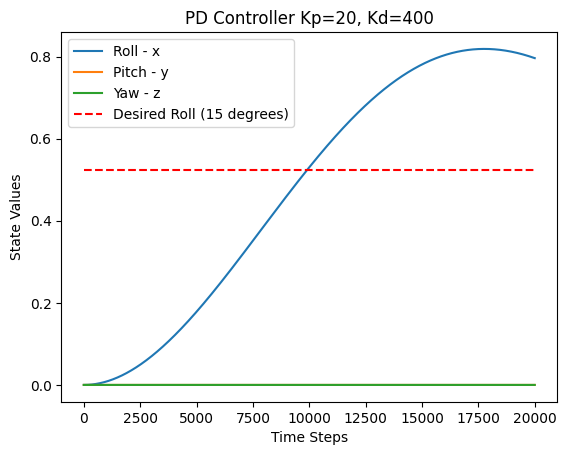

In [36]:
my_sat.plot()

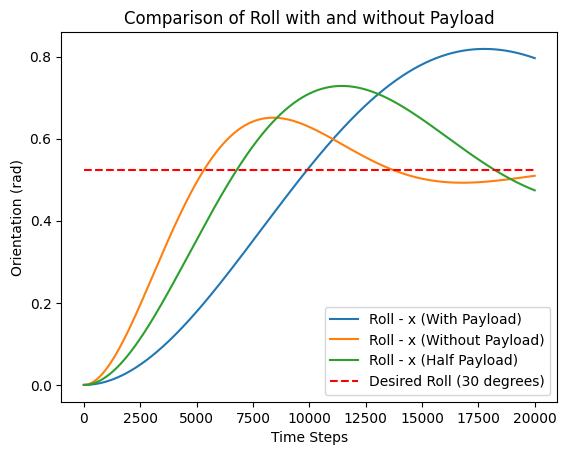

In [42]:
plt.figure()
plt.plot(my_sat.x[0, :], label='Roll - x (With Payload)')
plt.plot(my_sat_nopay.x[0, :], label='Roll - x (Without Payload)')
plt.plot(my_sat_halfpay.x[0, :], label='Roll - x (Half Payload)')
plt.title('Comparison of Roll with and without Payload')
plt.hlines(y=np.pi/6, xmin=0, xmax=my_sat.x.shape[1]-1, colors='r', linestyles='dashed', label='Desired Roll (30 degrees)')
plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Orientation (rad)')
plt.show()

## Results


## Conculsion
From the graph we can conclude that the PD controller has lower performance as the payload attached moves away from the principal axis

In [ ]:
jupyter nbconvert --execute --to markdown sim.ipynb